# Homework 05: NumPy Arrays and Linear Algebra

**Release Date:** Mar 8

**Due Date:** Mar 27 11:59 PM

**Total Points:** 80 pts

**Instructions:**
- Complete all problems in this notebook
- Show all your work with clear comments
- Use NumPy arrays for all calculations
- Format all outputs professionally with units
- Test your code to ensure it runs without errors

**Submission:**
- Submit this completed Jupyter notebook to Gradescope
- Make sure all cells have been executed and outputs are visible

---
## Problem 1 (30 points) – Temperature Profile in a Reactor

A tubular reactor has temperature measurements at 8 equally-spaced positions along its length ($L$ = 10 m). The temperatures (in K) are stored in a NumPy array:

```python
temperatures = np.array([450, 475, 490, 510, 525, 515, 495, 470])
```

**Tasks:**

a) **(5 pts)** Calculate and print:
   - Mean temperature
   - Maximum temperature and its position (index)
   - Minimum temperature and its position (index)
   - Temperature range (max - min)

b) **(5 pts)** Find all positions where the temperature exceeds 500 K using NumPy boolean indexing.

c) **(10 pts)** Calculate the temperature gradient (temperature difference between consecutive positions):

   $$
   \frac{dT}{dx} \approx \frac{T_{i+1} - T_i}{\Delta x}
   $$
   
   Print the gradient array and identify where the largest temperature drop occurs.




d) **(10 pts)** Normalize the temperature array to a 0-1 scale using:
   $$T_{norm} = \frac{T - T_{min}}{T_{max} - T_{min}}$$
   
   Print the normalized array and verify that the minimum value is 0 and maximum is 1.

   This dimensionless temperature maps each position to "how far along it is between the coldest and hottest point in the reactor" — where **0** corresponds to the coldest location and **1** to the peak temperature. This is physically useful for comparing the *shape* of temperature profiles across reactors with different absolute temperatures, and the same form appears naturally as a boundary condition in analytical solutions to the heat equation.

---
## Problem 2 (20 points) – Material Balance using Linear Algebra

A mixing unit receives three feed streams and produces one outlet stream. The mass flow rates and compositions must satisfy material balances.

**Given:**
- Stream 1: Flow rate F₁ (kg/h), composition: 50% A, 30% B, 20% C
- Stream 2: Flow rate F₂ (kg/h), composition: 20% A, 50% B, 30% C
- Stream 3: Flow rate F₃ (kg/h), composition: 30% A, 20% B, 50% C

**Outlet specifications:**
- Total flow rate: 800 kg/h
- Component A: 320 kg/h
- Component B: 280 kg/h

Run this for visualization: 

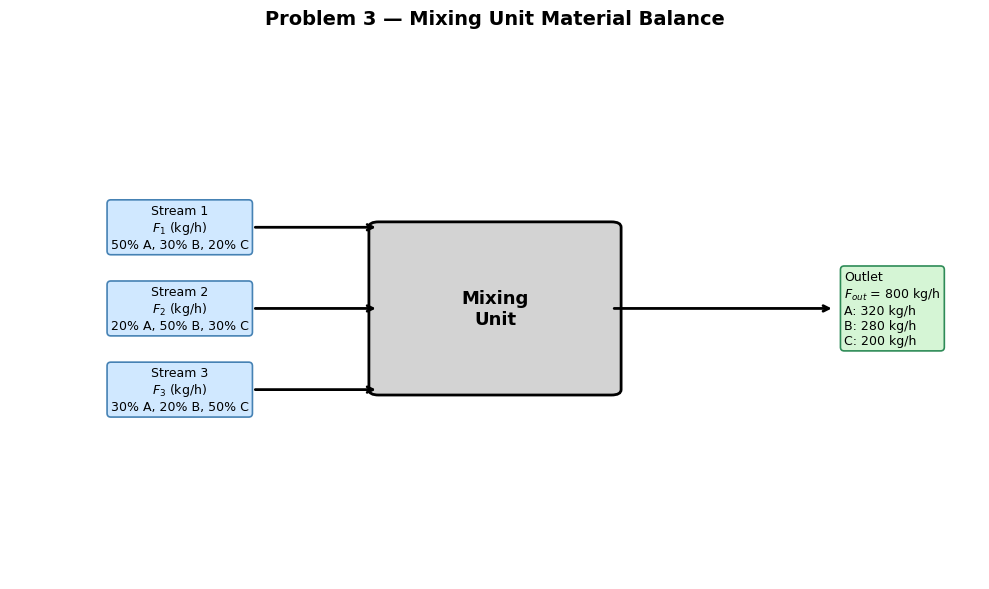

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# ── Mixing box ────────────────────────────────────────────────────────────────
box = mpatches.FancyBboxPatch((3.8, 3.5), 2.4, 3.0,
                               boxstyle="round,pad=0.1",
                               linewidth=2, edgecolor='black',
                               facecolor='lightgray')
ax.add_patch(box)
ax.text(5.0, 5.0, 'Mixing\nUnit', ha='center', va='center',
        fontsize=13, fontweight='bold')

# ── Helper: draw an arrow ─────────────────────────────────────────────────────
def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# ── Feed streams (left side) ──────────────────────────────────────────────────
stream_data = [
    (1, 6.5, 'Stream 1\n$F_1$ (kg/h)\n50% A, 30% B, 20% C'),
    (1, 5.0, 'Stream 2\n$F_2$ (kg/h)\n20% A, 50% B, 30% C'),
    (1, 3.5, 'Stream 3\n$F_3$ (kg/h)\n30% A, 20% B, 50% C'),
]

for (x_start, y_start, label) in stream_data:
    arrow(ax, x_start + 1.5, y_start, 3.8, y_start)
    ax.text(x_start + 0.75, y_start, label, ha='center', va='center',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='#d0e8ff', edgecolor='steelblue', lw=1.2))

# ── Outlet stream (right side) ────────────────────────────────────────────────
arrow(ax, 6.2, 5.0, 8.5, 5.0)
ax.text(8.6, 5.0,
        'Outlet\n$F_{out}$ = 800 kg/h\nA: 320 kg/h\nB: 280 kg/h\nC: 200 kg/h',
        ha='left', va='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#d5f5d5',
                  edgecolor='seagreen', lw=1.2))

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title('Problem 3 — Mixing Unit Material Balance', fontsize=14,
             fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

**Tasks:**

a) **(10 pts)** Solve for F₁, F₂, F₃

b) **(10 pts)** Verify that component C balance is satisfied (should equal 200 kg/h) and check that all flow rates are positive and physically meaningful

---
## Problem 3 (30 points): Arrhenius Analysis — Extracting Kinetic Parameters from Data

The **Arrhenius equation** describes how reaction rate constants vary with temperature:

$$
k = A \, e^{-E_a / (RT)}
$$

Taking the natural log linearizes this:

$$
\ln k = \ln A - \frac{E_a}{R} \cdot \frac{1}{T}
$$

So a plot of $\ln k$ vs $1/T$ should be a straight line with **slope** $= -E_a/R$ and **intercept** $= \ln A$.

A laboratory measured the following rate constants for the decomposition of N₂O₅:

| T (K) | k (s⁻¹) |
|-------|---------|
| 273 | 7.87 × 10⁻⁷ |
| 298 | 3.46 × 10⁻⁵ |
| 318 | 4.98 × 10⁻⁴ |
| 338 | 4.87 × 10⁻³ |
| 358 | 3.50 × 10⁻² |

**Tasks:**

a) (20 pts) Create an **Arrhenius plot**: $\ln k$ vs $1/T$ (×10³ for readability on the x-axis). Print $E_a$ (kJ/mol) and $A$ (s⁻¹) clearly with units.

b) (10 pts) **In a markdown cell below your code**, write 2–3 sentences: *What does a higher $E_a$ physically mean for a reaction? Based on your fitted $E_a$, is the N₂O₅ decomposition highly temperature-sensitive?*

**Physical interpretation:**
(your answer)

---

**Point Distribution:**
- Problem 1: 30 pts
- Problem 2: 20 pts
- Problem 3: 30 pts
- **Total: 80 pts)**

Good luck!